# Frontier RCCL-Allreduce — Plots

Raw data = OSU text output under `results/sweep/N<nodes>_job<id>/{A,B,C,D}_*.txt` (main sweep)
and `results_ml/` (ML gradient-sync at exact model sizes), parsed in **cell 1** into DataFrames
`data` and `data_ml`. Each point is the **median across reps** (3 reps at 1–2048 nodes, 2 at 4096;
each rep = mean over 50 iterations, 10 warm-ups). **Cell 2** defines the styling and all plot
functions (collapse it to hide the code). Every cell after that is a **one-line call**.

Each axis shows a small italic "lower/higher is better" note beside its label. Configs:
MPICH (host CPU) / MPICH (device) / **MPICH-RCCL** / Cray MPICH.

Message-size coverage (intentional, not data gaps):
- **MPICH-RCCL (C): 8 B → 1 GiB at every node count (1–4096).** 1 GiB is OSU's ceiling (32-bit message size).
- **Cray MPICH (D): to 1 GiB at ≤512 nodes, but only to 4 MiB at ≥1024** — Cray's GPU-aware
  allreduce crashes (GPU memory access fault) above 4 MiB at scale, so its curves stop there
  (gray cells in the heatmap).
- **CPU paths (A/B): capped at 32 MiB** — host reductions are prohibitively slow at large sizes.

In [136]:
# === Cell 1: load & clean the sweep data =================================
import os, re, glob
import numpy as np, pandas as pd

RESULTS = "results/sweep" if os.path.isdir("results/sweep") else "../results/sweep"

OSU_FILES = {"A":"A_mpich_host.txt","B":"B_mpich_dev.txt",
             "C":"C_mpich_rccl.txt","D":"D_cray_gpuaware.txt"}
LABEL = {"A":"MPICH (host CPU)","B":"MPICH (device)","C":"MPICH-RCCL",
         "D":"Cray MPICH","E":"RCCL (rccl-tests)"}

def parse_osu(path):
    out = []
    for line in open(path):
        p = line.split()
        if len(p) >= 2 and p[0].isdigit():
            try:
                out.append((int(p[0]), float(p[1]),
                            float(p[2]) if len(p) > 2 else np.nan,
                            float(p[3]) if len(p) > 3 else np.nan))
            except ValueError:
                pass
    return out

rows = []
for d in sorted(glob.glob(os.path.join(RESULTS, "N*_job*"))):
    m = re.match(r"N(\d+)_job(\d+)", os.path.basename(d))
    if not m:
        continue
    nodes, job = int(m.group(1)), int(m.group(2))
    for cfg, fn in OSU_FILES.items():
        fp = os.path.join(d, fn)
        if os.path.exists(fp):
            for s, a, mn, mx in parse_osu(fp):
                rows.append(dict(nodes=nodes, job=job, config=cfg, size=s, avg=a, min=mn, max=mx))

raw = pd.DataFrame(rows); raw = raw[raw["avg"] > 0]
data = (raw.groupby(["nodes","config","size"], as_index=False)
           .agg(avg=("avg","median"), std=("avg","std"), nreps=("job","nunique")))   # median across reps: robust to one bad-placement rep

# Path-2 ML data (exact model-gradient sizes) if results_ml/ is present; else plot_ml_sync uses Path 1.
ML_RESULTS = "results_ml" if os.path.isdir("results_ml") else "../results_ml"
ml_rows = []
for d in sorted(glob.glob(os.path.join(ML_RESULTS, "N*_job*"))):
    m = re.match(r"N(\d+)_job(\d+)", os.path.basename(d))
    if not m:
        continue
    for cfg, fn in OSU_FILES.items():
        fp = os.path.join(d, fn)
        if os.path.exists(fp):
            for s, a, mn, mx in parse_osu(fp):
                ml_rows.append(dict(nodes=int(m.group(1)), job=int(m.group(2)), config=cfg, size=s, avg=a))
_mlraw = pd.DataFrame(ml_rows)
data_ml = (_mlraw[_mlraw["avg"] > 0]
           .groupby(["nodes","config","size"], as_index=False)
           .agg(avg=("avg","median"), nreps=("job","nunique"))) if len(ml_rows) else None

print("main sweep nodes:", sorted(data.nodes.unique()), "| sizes:", data["size"].nunique(),
      "| ML Path-2:", ("loaded, nodes " + str(sorted(data_ml.nodes.unique()))) if data_ml is not None else "none (uses Path 1)")
data.head()

main sweep nodes: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048), np.int64(4096)] | sizes: 29 | ML Path-2: loaded, nodes [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048), np.int64(4096)]


,nodes,config,size,avg,std,nreps
0,1,A,4,17.28,3.151545,3
1,1,A,8,16.95,0.181475,3
2,1,A,16,16.86,0.122202,3
3,1,A,32,27.48,0.200333,3
4,1,A,64,28.20,0.705856,3


In [137]:
# === Cell 2: style + plot functions  (collapse this cell to hide the code) =
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import TwoSlopeNorm

mpl.rcParams["font.family"] = "STIXGeneral"; mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams.update({"font.size":18,"axes.titlesize":22,"axes.labelsize":20,
                     "legend.fontsize":13,"xtick.labelsize":16,"ytick.labelsize":16})

SPEEDUP_COLOR = "#2ca02c"          # green reserved for the speedup line only
LAT_MAIN = "Latency (\u00b5s, log)"
SPD_MAIN = lambda base: f"{LABEL['C']} speedup vs {LABEL[base]}"
STYLE = {   # all data lines uniform: solid, circle markers, same weight (distinguished by color)
    "A": dict(color="#616161", marker="o", linestyle="-", linewidth=2, markersize=5, label=LABEL["A"]),
    "B": dict(color="#1f77b4", marker="o", linestyle="-", linewidth=2, markersize=5, label=LABEL["B"]),
    "C": dict(color="#d62728", marker="o", linestyle="-", linewidth=2, markersize=5, label=LABEL["C"]),
    "D": dict(color="#7e4bbd", marker="o", linestyle="-", linewidth=2, markersize=5, label=LABEL["D"]),
}
ORDER = ["A","B","C","D"]           # E (pure RCCL) parsed but not plotted

def sci(x,_):
    if x <= 0: return "0"
    e = int(np.floor(np.log10(x))); b = x/10**e
    return rf"${int(round(b))}\times10^{{{e}}}$"

def human(nb):
    nb = float(nb)
    for u in ["B","KiB","MiB","GiB"]:
        if nb < 1024: return f"{int(nb)} {u}"
        nb /= 1024
    return f"{int(nb)} TiB"

def parse_size(x):
    # accept "1MiB", "512KiB", "1GiB", "8B", "1kb", ... or a raw byte count
    if isinstance(x, (int, float)): return int(x)
    s = str(x).strip().lower().replace(" ", "")
    for suf, m in [("gib",1024**3),("gb",1024**3),("mib",1024**2),("mb",1024**2),
                   ("kib",1024),("kb",1024),("b",1),("g",1024**3),("m",1024**2),("k",1024)]:
        if s.endswith(suf):
            return int(float(s[:-len(suf)]) * m)
    return int(float(s))

def series(nodes, config):
    d = data[(data.nodes==nodes)&(data.config==config)].sort_values("size")
    return d["size"].values, d["avg"].values

def ylabel2(ax, main, sub, side="left"):
    # main axis label + a small italic light-gray "sub" line just outboard of it
    if side == "left":
        lbl = ax.set_ylabel(main); rot, dx = 90, -20
    else:
        lbl = ax.set_ylabel(main, rotation=270, labelpad=42); rot, dx = 270, 20
    ax.annotate(sub, xy=(0.5,0.5), xycoords=lbl, textcoords="offset points",
                xytext=(dx,0), rotation=rot, ha="center", va="center",
                fontsize=12.5, style="italic", color="#444444")

def finish(fig):
    fig.patch.set_facecolor("white"); fig.tight_layout(); plt.show()

def plot_latency_vs_size(nodes, speedup_over="D"):
    fig, ax1 = plt.subplots(figsize=(16,10))
    for cfg in ORDER:
        x,y = series(nodes,cfg)
        if len(x): ax1.plot(x,y,**STYLE[cfg])
    ax1.set_xscale("log", base=2); ax1.set_yscale("log")
    ax1.set_xlabel("Message size (bytes, log2)")
    ylabel2(ax1, LAT_MAIN, "lower is better", "left")
    ax1.set_title(f"Allreduce latency: {nodes} node(s)")
    ax1.yaxis.set_major_formatter(FuncFormatter(sci)); ax1.grid(True, which="both", ls="--", alpha=0.4)
    xc,yc = series(nodes,"C"); xb,yb = series(nodes,speedup_over)
    if len(xc) and len(xb):
        common = np.intersect1d(xc,xb)
        sc = np.array([yb[list(xb).index(s)]/yc[list(xc).index(s)] for s in common])
        ax2 = ax1.twinx()
        ax1.set_zorder(ax2.get_zorder()+1); ax1.patch.set_visible(False)   # data lines above the ax2 baseline
        ax2.plot(common, sc, marker="o", linestyle="--", color=SPEEDUP_COLOR, lw=2, label=f"{LABEL['C']} speedup vs {LABEL[speedup_over]}")
        ax2.axhline(1, color="#aaaaaa", ls="--", lw=1.5, zorder=0); ax2.set_yscale("log", base=2)
        ylabel2(ax2, SPD_MAIN(speedup_over), "higher is better", "right")
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda y,_: (f"{y:g}" if y>=1 else "")))
        i = int(np.argmax(sc))
        ax2.annotate(f"{sc[i]:.1f}\u00d7", xy=(common[i],sc[i]), xytext=(common[i], sc[i]*0.6),
                     fontsize=15, bbox=dict(fc="white",ec="black",boxstyle="round,pad=0.3"),
                     arrowprops=dict(arrowstyle="->"))
        h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1+h2, l1+l2, loc="upper left", framealpha=1)
    else:
        ax1.legend(loc="upper left", framealpha=1)
    finish(fig)

def plot_speedup_vs_size(baseline="D"):
    fig, ax = plt.subplots(figsize=(16,10))
    for n in sorted(data.nodes.unique()):
        xc,yc = series(n,"C"); xb,yb = series(n,baseline)
        common = np.intersect1d(xc,xb)
        if not len(common): continue
        sc = np.array([yb[list(xb).index(s)]/yc[list(xc).index(s)] for s in common])
        ax.plot(common, sc, marker="o", linestyle="-", lw=2, label=f"{n} nodes")
    ax.axhline(1, color="#aaaaaa", ls="--", lw=1.5, zorder=0)
    ax.set_xscale("log", base=2); ax.set_yscale("log", base=2)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y,_: (f"{y:g}" if y>=1 else "")))
    ax.set_xlabel("Message size (bytes, log2)")
    ylabel2(ax, SPD_MAIN(baseline), "higher is better", "left")
    ax.set_title(f"{LABEL['C']} speedup over {LABEL[baseline]} (per node count)")
    ax.grid(True, which="both", ls="--", alpha=0.4); ax.legend(title="scale", framealpha=1, ncol=2)
    finish(fig)

def plot_scaling(size):
    size = parse_size(size)
    fig, ax = plt.subplots(figsize=(16,10))
    for cfg in ORDER:
        d = data[(data.config==cfg)&(data["size"]==size)].sort_values("nodes")
        if len(d): ax.plot(d.nodes, d.avg, **STYLE[cfg])
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.set_xticks(sorted(data.nodes.unique()))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{int(x)}"))
    ax.set_xlabel("Nodes")
    ylabel2(ax, LAT_MAIN, "lower is better", "left")
    ax.set_title(f"Allreduce scaling @ {human(size)}")
    ax.yaxis.set_major_formatter(FuncFormatter(sci)); ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(framealpha=1)
    finish(fig)

def plot_crossover(baseline="D", annotate=True, vmax=None):
    # linear diverging color centered at 1x (= equal); extremes saturate red/blue.
    # cell text = linear speedup (>1 = MPICH-RCCL faster). vmax caps the red end.
    pc = data[data.config=="C"].pivot_table(index="size", columns="nodes", values="avg")
    pb = data[data.config==baseline].pivot_table(index="size", columns="nodes", values="avg")
    cols = sorted(set(pc.columns)&set(pb.columns)); idx = sorted(set(pc.index)&set(pb.index))
    lin = (pb.loc[idx,cols] / pc.loc[idx,cols])          # linear speedup: MPICH-RCCL / baseline (1 = equal)
    lo = min(np.nanmin(lin.values), 0.99)
    hi = vmax if vmax is not None else max(np.nanmax(lin.values), 1.01)
    norm = TwoSlopeNorm(vmin=lo, vcenter=1.0, vmax=hi)
    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad("#555555")              # gray = no data (missing cell, e.g. Cray aborts >4 MiB at >=1024 nodes)
    fig, ax = plt.subplots(figsize=(12,9))
    im = ax.imshow(lin.values, cmap=cmap, norm=norm, origin="lower", aspect="auto")
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols)
    ax.set_yticks(range(len(idx)));  ax.set_yticklabels([human(s) for s in idx], fontsize=9)
    ax.set_xlabel("Nodes"); ax.set_ylabel("Message size")
    if annotate:
        for i in range(len(idx)):
            for j in range(len(cols)):
                v = lin.values[i,j]
                if np.isnan(v): continue
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9,
                        color="white" if (v > 2.5 or v < 0.5) else "black")
    ax.set_title(f"{LABEL['C']} vs {LABEL[baseline]}")
    cb = fig.colorbar(im, ax=ax)
    cb.set_label(f"speedup: {LABEL['C']} / {LABEL[baseline]}", rotation=270, labelpad=22)
    # same styled note as the axis labels, beside the colorbar label (clip off so the narrow bar doesn't hide it)
    cb.ax.annotate(f"1 = equal;  red = {LABEL['C']} faster;  gray = no {LABEL[baseline]} data", xy=(0.5,0.5),
                   xycoords=cb.ax.yaxis.label, textcoords="offset points", xytext=(20,0),
                   rotation=270, ha="center", va="center", fontsize=12.5,
                   style="italic", color="#444444", annotation_clip=False)
    finish(fig)

# ---- ML gradient-sync proxy (see docs/ML_EXPERIMENT.md) -----------------------------
# Reframe the main sweep as per-step gradient-allreduce time. Comm is byte-bound, so the
# nearest power-of-2 sweep size proxies each model's gradient (32 MiB<->25 MiB DDP bucket,
# 128 MiB<->ResNet-50 ~102 MB, 512 MiB<->BERT-Large fp16 ~680 MB). Weak scaling: per-rank
# gradient size fixed, node count grows. (Path 2 / run_ml_sync.sbatch measures exact sizes.)
ML_MODELS = [   # (label, exact gradient bytes, nearest power-of-2 in main sweep, line color)
    ("DDP bucket: 25 MiB",       26214400,   33554432,   "#ee7733"),   # PyTorch DDP default bucket_cap_mb=25
    ("ResNet-50: 102 MB",        102228128,  134217728,  "#009988"),   # 25.6 M params x 4 B
    ("BERT-Large fp16: 680 MB",  680000000,  536870912,  "#aa3377"),   # 340 M params x 2 B
    ("BERT-Large fp32: 1.36 GB",  1360000000, 1073741824, "#4477aa"),   # 340 M params x 4 B (near: ~1 GiB)
]

def ml_sync_table(baseline="D", source="exact"):
    # source="exact" -> results_ml at exact model sizes; "near" -> main sweep at nearest power-of-2
    src = data_ml if source == "exact" else data
    r = []
    for label, sz_exact, sz_near, _ in ML_MODELS:
        sz = sz_exact if source == "exact" else sz_near
        for n in sorted(src.nodes.unique()):
            def lat(cfg):
                d = src[(src.nodes==n) & (src.config==cfg) & (src["size"]==sz)]
                return float(d.avg.iloc[0]) if len(d) else np.nan
            c, base, b = lat("C"), lat(baseline), lat("B")
            r.append(dict(model=label, nodes=n,
                          rccl_ms  = c/1000.0,                                       # MPICH-RCCL per-step sync
                          base_ms  = base/1000.0,                                    # baseline per-step sync
                          eff_GBps = (sz/(c*1e-6))/1e9 if c == c else np.nan,         # RCCL effective bus BW
                          speedup  = base/c if (c == c and base == base) else np.nan, # RCCL speedup vs baseline
                          vs_MPICH = b/c if (c == c and b == b) else np.nan))         # C/B (device-CPU)
    return pd.DataFrame(r)

# speedup-line colors: lighter-but-bright (neon) counterparts of each model color
SPD_NEON = {"#ee7733": "#ffb424",    # orange  -> bright amber
            "#009988": "#00e6c3",    # teal    -> neon aqua
            "#aa3377": "#ff64c8",    # magenta -> hot pink
            "#4477aa": "#55c8ff"}    # blue    -> bright sky

def plot_ml_sync(baseline="D", source="exact"):
    from matplotlib.lines import Line2D
    if source == "exact" and data_ml is None:
        print("no results_ml loaded — call plot_ml_sync(source='near') for the main-sweep estimate"); return
    src = data_ml if source == "exact" else data
    df = ml_sync_table(baseline, source)
    fig, ax = plt.subplots(figsize=(16,10)); ax2 = ax.twinx()   # right axis = RCCL speedup vs baseline
    ax.set_zorder(ax2.get_zorder()+1); ax.patch.set_visible(False)   # data lines above the ax2 baseline
    labels = []
    for label, sz_e, sz_n, col in ML_MODELS:
        labels.append(label if source == "exact" else f"{label} (~{human(sz_n)})")
        s = df[df.model == label].sort_values("nodes")
        rc = s.dropna(subset=["rccl_ms"])
        if len(rc): ax.plot(rc.nodes, rc.rccl_ms, marker="o", ls="-",  lw=2, ms=6, color=col)            # RCCL: solid circle
        bs = s.dropna(subset=["base_ms"])
        if len(bs): ax.plot(bs.nodes, bs.base_ms, marker="o", ls="--", lw=2, ms=6, color=col)            # baseline: dashed circle
        sp = s.dropna(subset=["speedup"])
        if len(sp): ax2.plot(sp.nodes, sp.speedup, marker="s", ls=":", lw=2, ms=6, color=SPD_NEON.get(col, col))  # speedup: neon, square
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y,_: f"{y:g}"))   # plain 1, 10, 100 (not 10^0)
    ax2.set_yscale("log", base=2); ax2.axhline(1, color="#aaaaaa", ls="--", lw=1.5, zorder=0)
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda y,_: (f"{y:g}" if y>=1 else "")))
    ax.set_xticks(sorted(src.nodes.unique()))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{int(x)}"))
    ax.set_xlabel("Nodes (weak scaling)")
    ylabel2(ax, "Per-step gradient-sync (ms, log)", "lower is better", "left")
    ylabel2(ax2, SPD_MAIN(baseline), "higher is better", "right")
    ax.set_title("Gradient-allreduce at model scales")
    ax.grid(True, which="both", ls="--", alpha=0.4)
    # legend 1: model = color (lower right)
    mh = [Line2D([0],[0], color=col, lw=2) for _,_,_,col in ML_MODELS]
    leg1 = ax.legend(mh, labels, title="model gradient", loc="lower right", framealpha=1)
    ax.add_artist(leg1)
    # legend 2 (untitled): line meaning (upper left)
    sh = [Line2D([0],[0], color="#444444", lw=2, ls="-",  marker="o"),
          Line2D([0],[0], color="#444444", lw=2, ls="--", marker="o"),
          Line2D([0],[0], color="#bbbbbb", lw=2, ls=":",  marker="s")]
    ax.legend(sh, [f"{LABEL['C']}  (solid)", f"{LABEL[baseline]}  (dashed)", "RCCL speedup (right axis)"],
              loc="upper right", framealpha=1)
    finish(fig)
    return df

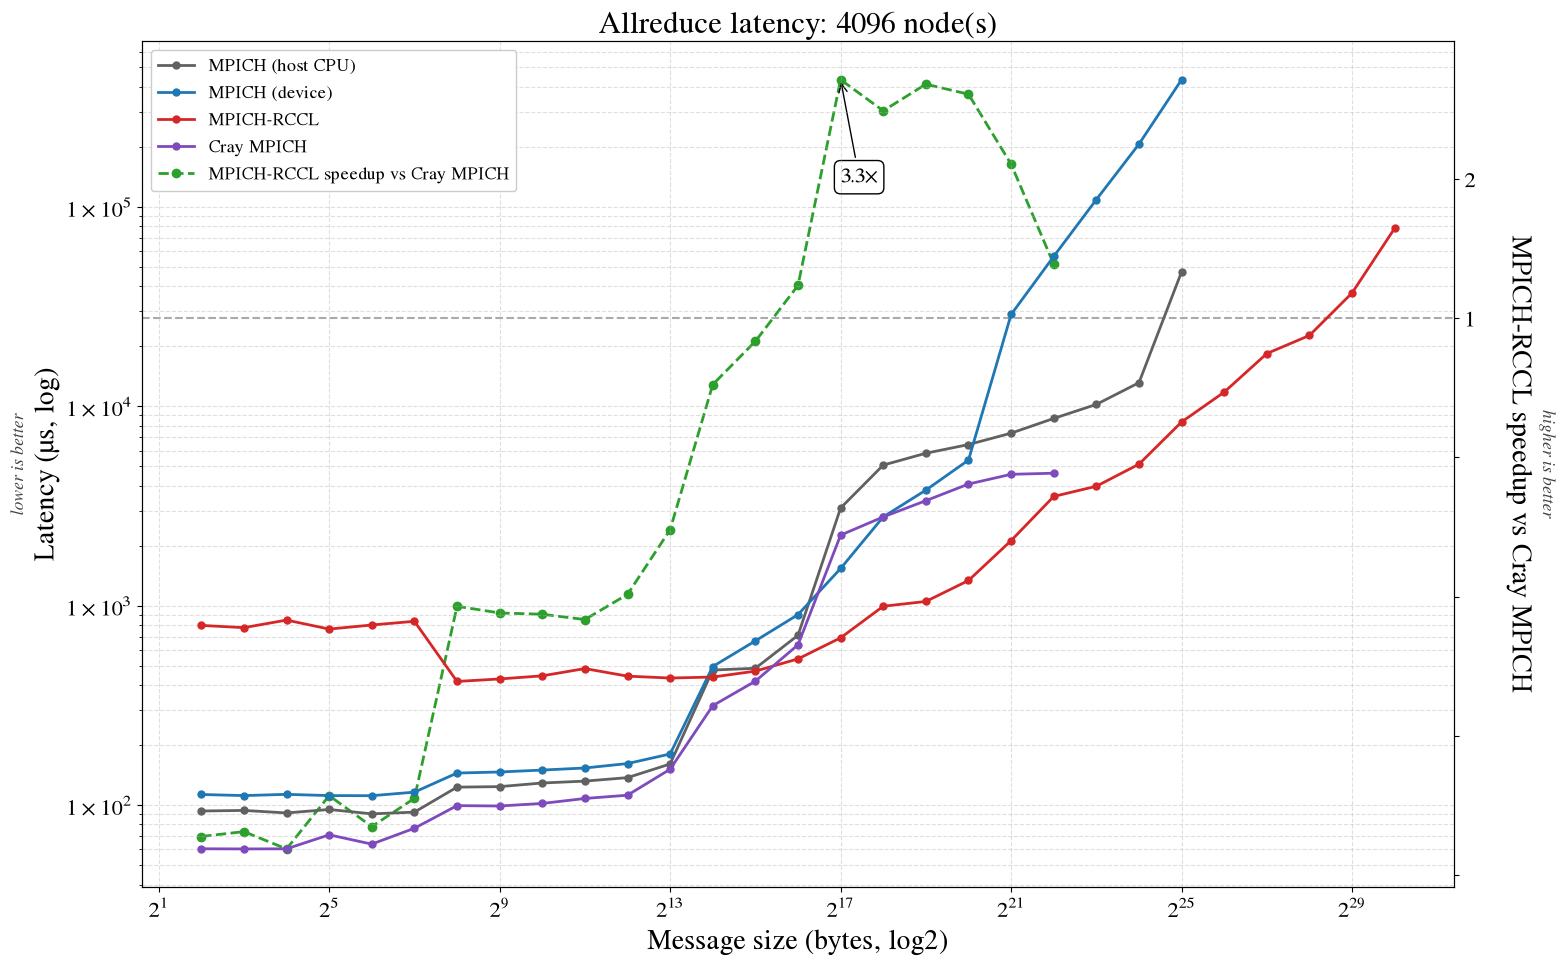

In [138]:
plot_latency_vs_size(4096)          # node count: 1, 2, 4, 8, ... 1024, 2048, 4096

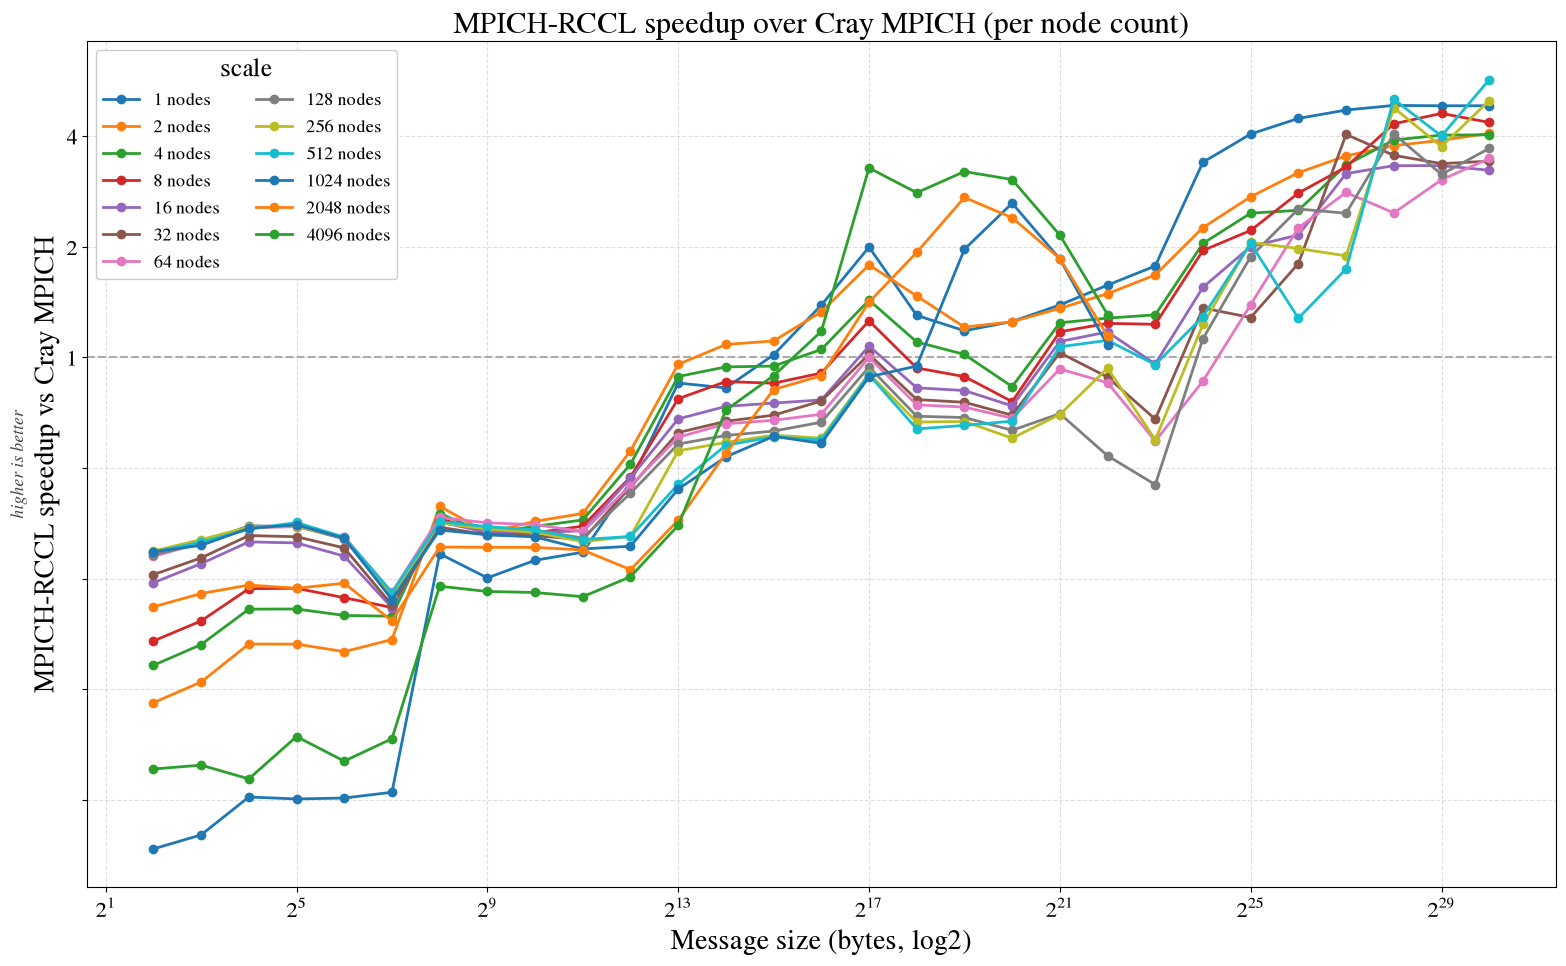

In [139]:
plot_speedup_vs_size("D")        # baseline: "D"=Cray, "B"=MPICH (device)

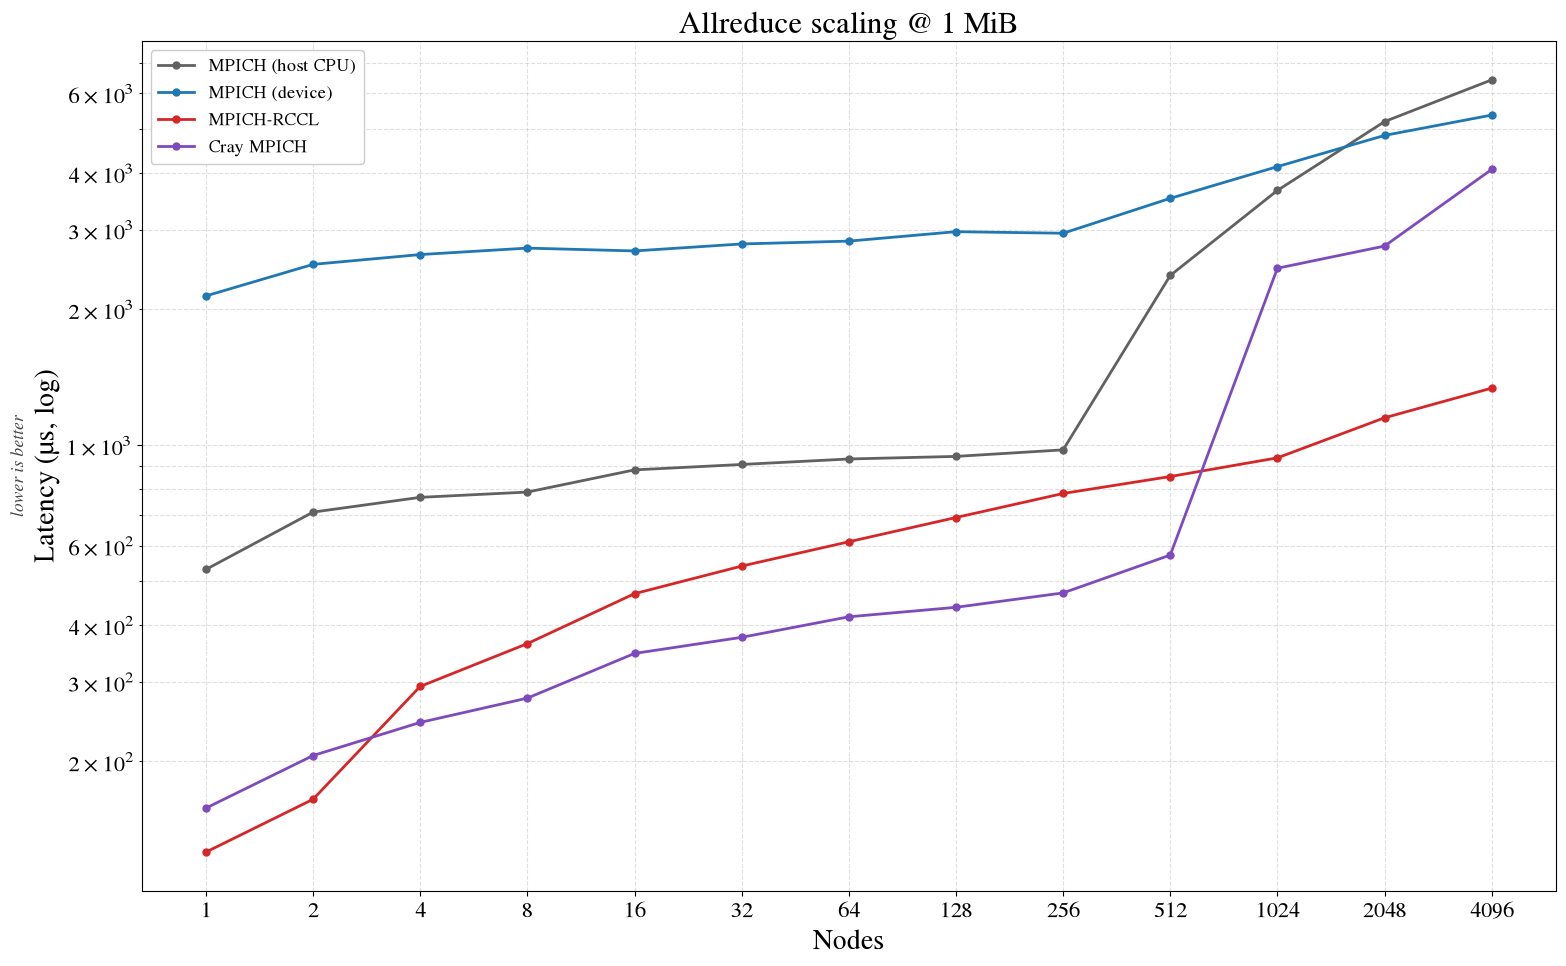

In [140]:
plot_scaling("1MiB")             # size: "1KiB", "16MiB", "1GiB", "2GiB", "4GiB", ... (raw bytes also ok)

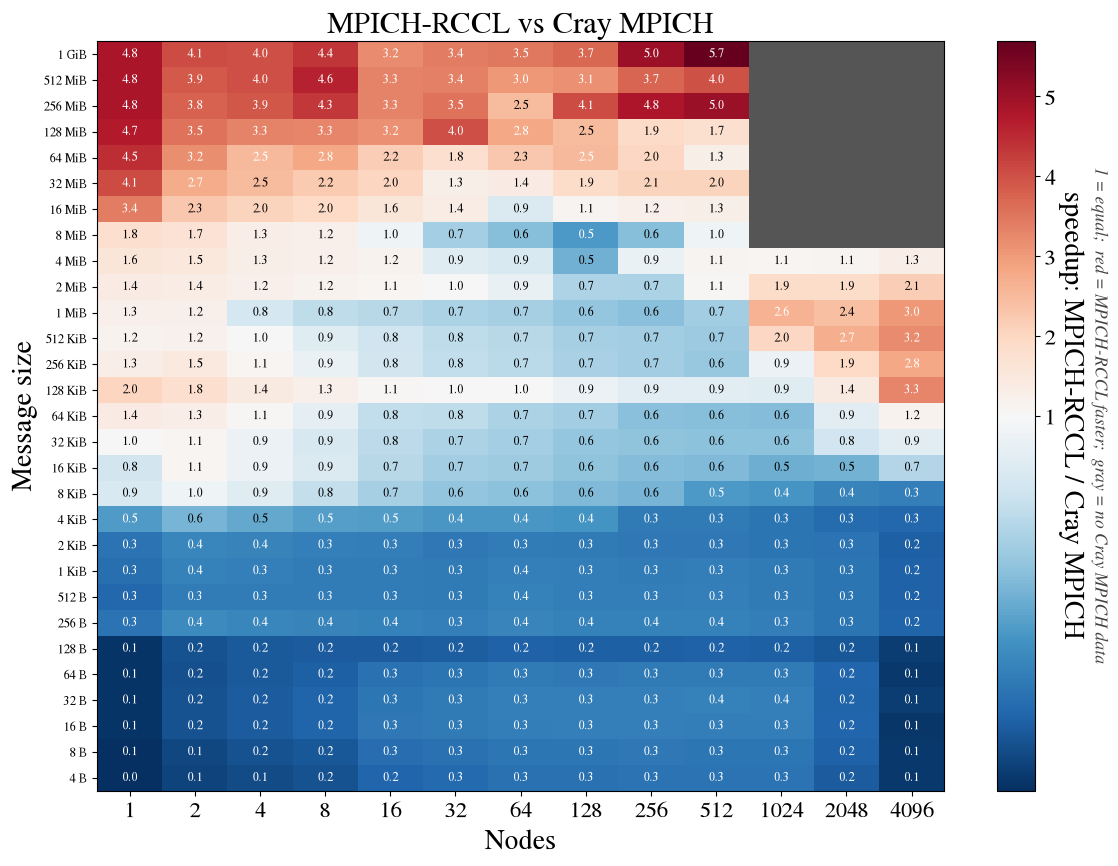

In [141]:
plot_crossover("D")              # crossover heatmap: red = MPICH-RCCL faster, gray = no Cray data

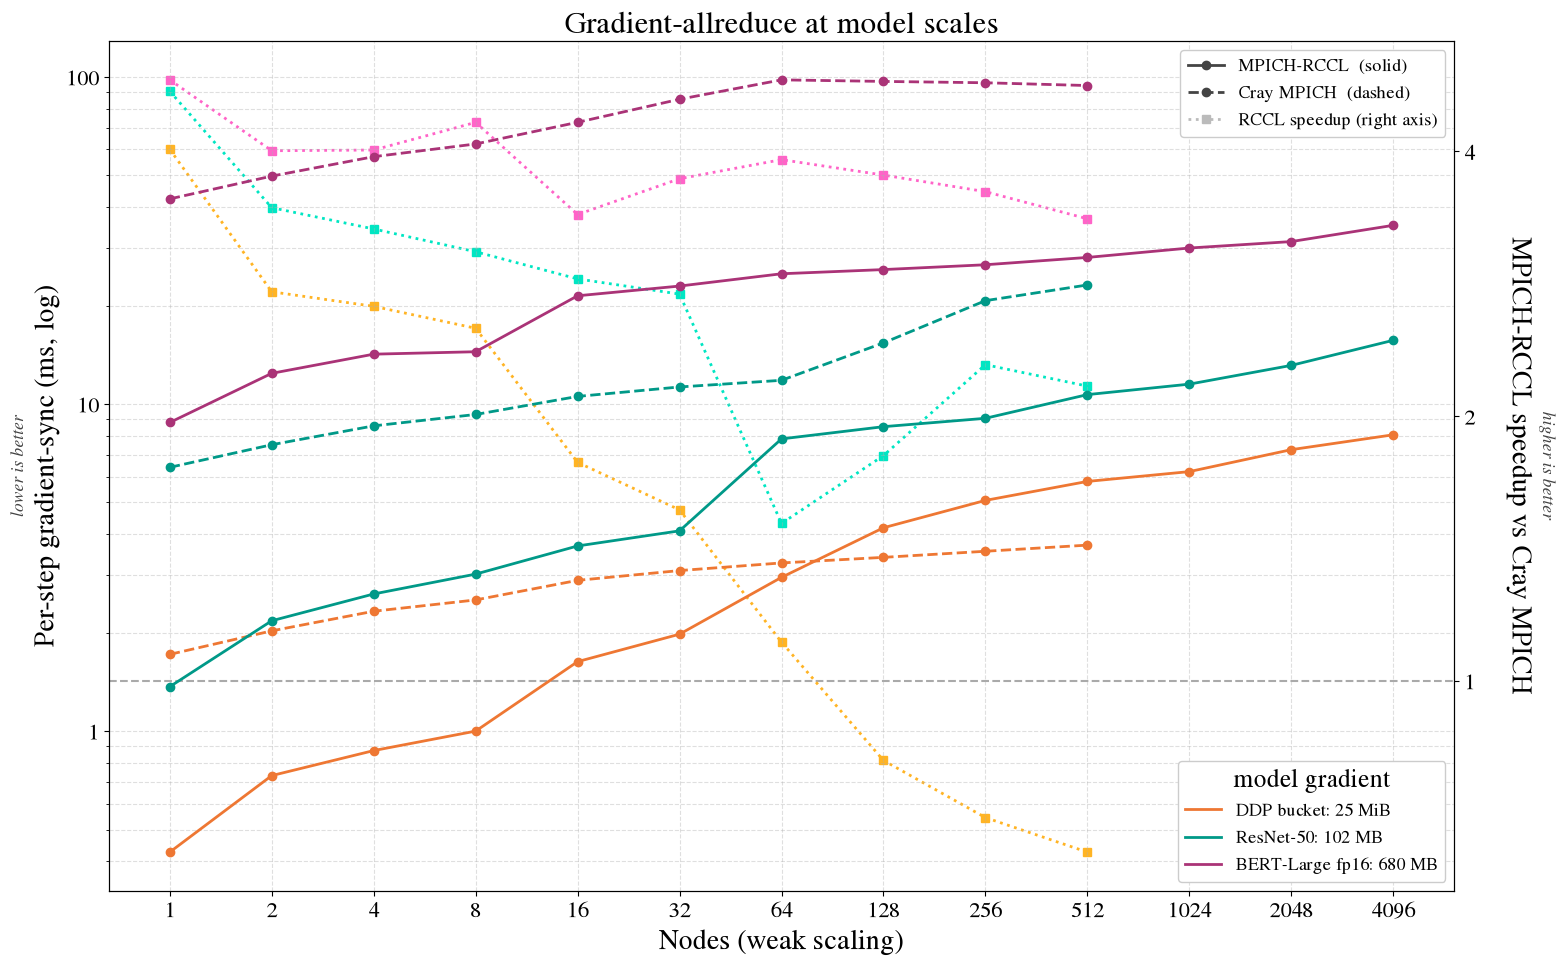

,model,nodes,rccl_ms,base_ms,eff_GBps,speedup,vs_MPICH
0,DDP bucket: 25 MiB,1,0.427,1.716,61.452,4.023,296.086
1,DDP bucket: 25 MiB,2,0.731,2.025,35.860,2.770,399.828
2,DDP bucket: 25 MiB,4,0.872,2.325,30.070,2.667,321.651
3,DDP bucket: 25 MiB,8,1.000,2.517,26.219,2.518,300.125
4,DDP bucket: 25 MiB,16,1.631,2.890,16.077,1.772,180.808
5,DDP bucket: 25 MiB,32,1.978,3.096,13.252,1.565,153.061
6,DDP bucket: 25 MiB,64,2.951,3.266,8.882,1.107,102.725
7,DDP bucket: 25 MiB,128,4.184,3.397,6.266,0.812,73.173
8,DDP bucket: 25 MiB,256,5.073,3.546,5.168,0.699,61.417
9,DDP bucket: 25 MiB,512,5.798,3.703,4.521,0.639,53.629


In [142]:
# ML gradient-sync (2 plots). solid=RCCL, dashed=Cray (both circles); light dotted square = RCCL speedup (right axis)
df_ml = plot_ml_sync("D", source="exact")   # (1) exact model sizes (results_ml)
# plot_ml_sync("D", source="near")             # (2) nearest power-of-2 estimate (main sweep)
df_ml.round(3)